<a href="https://colab.research.google.com/github/Arwa-2004/Arwa-2004/blob/main/Copy_of_Census_Data_Arwa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Income Prediction from Census Data
**Aim:** Predict whether an individual earns more or less than $50K using demographic features from the UCI Census dataset.

**Pipeline:**
1. Data Loading
2. Cleaning
3. EDA
4. Feature Engineering
5. Modelling
6. Evaluation
7. Explainability
8. Error Analysis

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

All libraries imported successfully.


## Load Data

In [ ]:

df = pd.read_csv('/content/Copy of adult (2).csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Data Cleaning

1. Replace `' ?'` placeholder strings with NaN, then fill with `'Unknown'`
2. Strip trailing whitespace and dots from the `income` column (the raw CSV contains both `'<=50K'` and `'<=50K.'` variants)
3. Encode `income` as a binary target (0 = <=50K, 1 = >50K)

> **Note:** Cleaning is done *before* EDA so all visualisations reflect the final, consistent data.

In [ ]:
cols_with_missing = ['workclass', 'occupation', 'native-country']
df[cols_with_missing] = df[cols_with_missing].replace(' ?', np.nan)
df[cols_with_missing] = df[cols_with_missing].fillna('Unknown')

# --- 3b. Normalise the income column ---
# Raw data has four variants: '<=50K', '<=50K.', '>50K', '>50K.'
df['income'] = df['income'].str.strip().str.replace('.', '', regex=False)

# --- 3c. Binary target ---
df['income_binary'] = df['income'].map({'<=50K': 0, '>50K': 1})

# Verify no nulls remain
print('Null counts after cleaning:')
print(df.isnull().sum())
print(f"\nIncome distribution:\n{df['income'].value_counts()}")

Null counts after cleaning:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
income_binary     0
dtype: int64

Income distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

In [ ]:
print('Shape:', df.shape)
df.info()
df.describe()

Shape: (48842, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
 15  income_binary   48842 non-null  int64 
dtypes: int64(7), object(9)
memory usage: 6.0+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income_binary
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


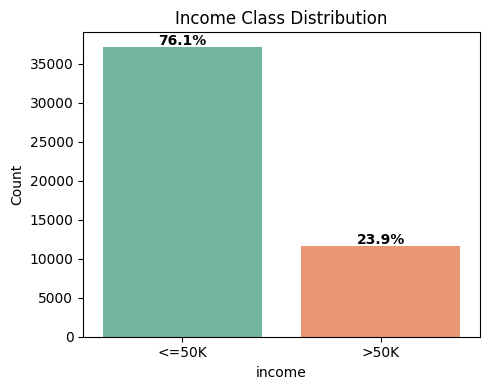

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


In [ ]:
# Target distribution
income_pct = df['income'].value_counts(normalize=True) * 100

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='income', palette='Set2')
plt.title('Income Class Distribution')
plt.ylabel('Count')
for i, (val, pct) in enumerate(zip(df['income'].value_counts().values, income_pct.values)):
    plt.text(i, val + 200, f'{pct:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(income_pct)

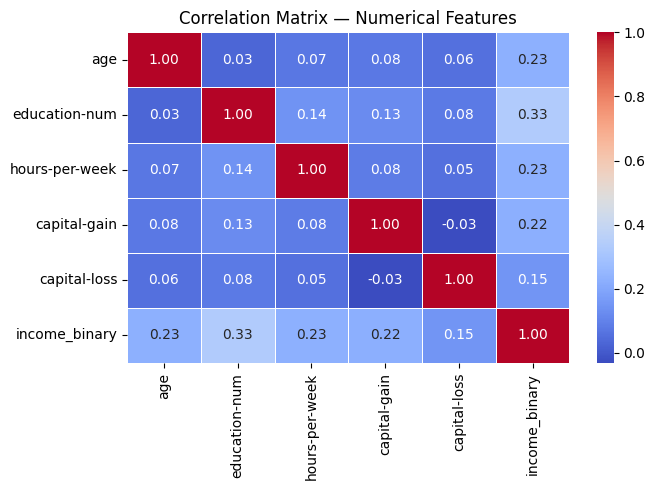

In [ ]:
# Correlation heatmap (numerical features)
num_features = ['age', 'education-num', 'hours-per-week',
                'capital-gain', 'capital-loss', 'income_binary']

corr = df[num_features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

# education-num has the highest correlation with income (0.33)

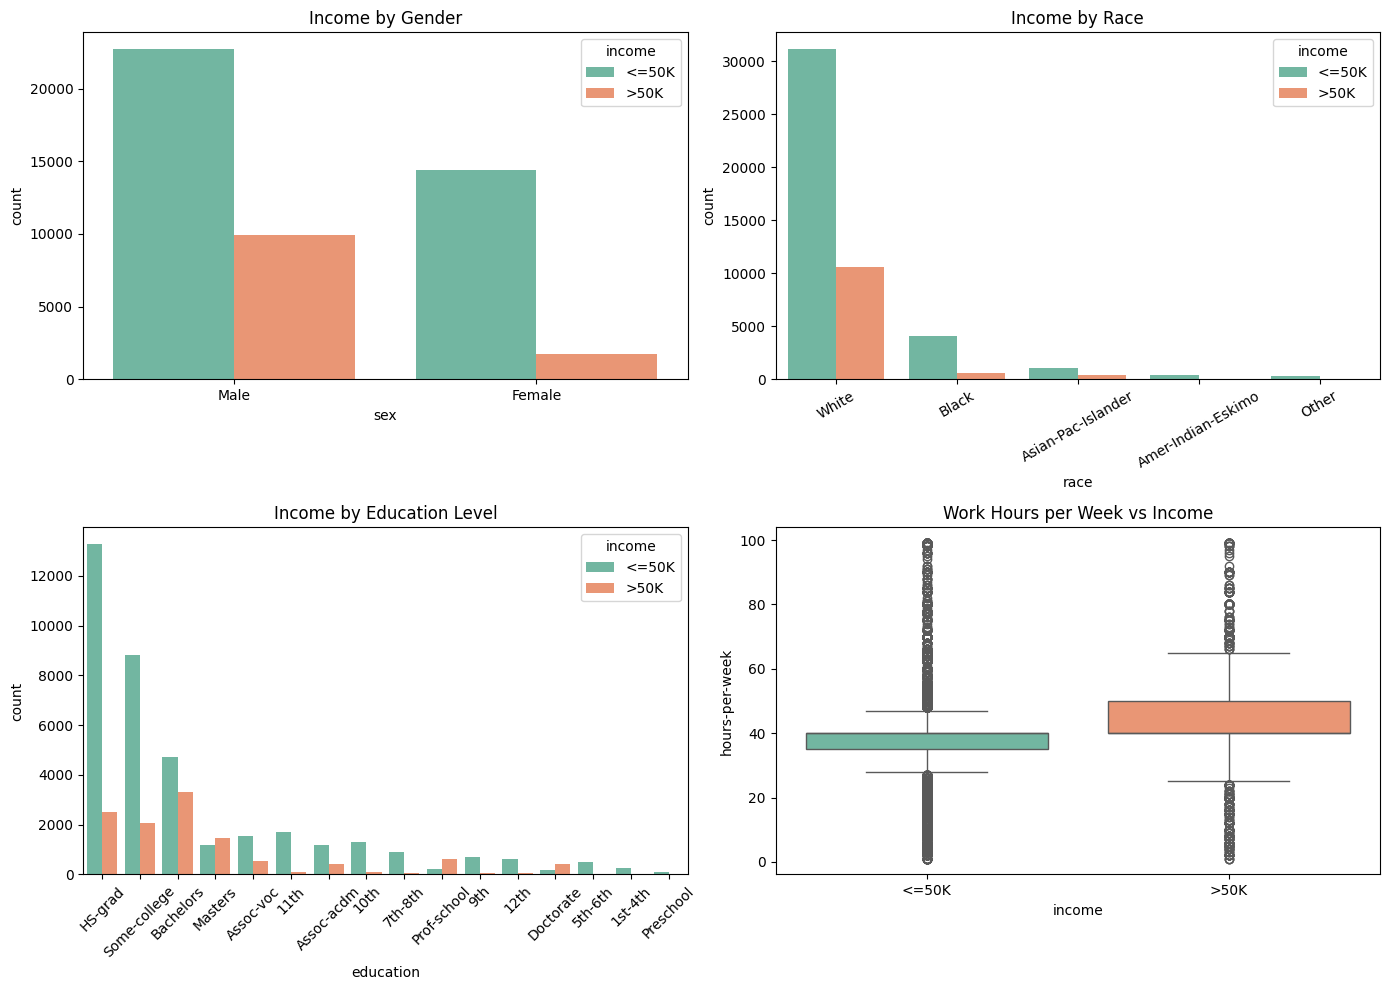

In [ ]:
# --- 4c. Categorical features vs income ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
sns.countplot(data=df, x='sex', hue='income', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Income by Gender')

# Race
sns.countplot(data=df, x='race', hue='income', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Income by Race')
axes[0, 1].tick_params(axis='x', rotation=30)

# Education
sns.countplot(data=df, x='education', hue='income', palette='Set2',
              order=df['education'].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title('Income by Education Level')
axes[1, 0].tick_params(axis='x', rotation=45)

# Hours per week
sns.boxplot(data=df, x='income', y='hours-per-week', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Work Hours per Week vs Income')

plt.tight_layout()
plt.show()

## Feature Engineering

**Rationale for categorical features included in modelling:**
- `workclass`, `occupation`, `marital-status`, `relationship`, `race`, `sex` are all label-encoded so the model can use them.
- `education` and `age` are binned into meaningful groups to reduce noise.
- An interaction term `education × hours` captures the combined effect of qualification and effort.

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 100],
                         labels=['young', 'mid', 'senior'])

# Education group
education_map = {
    'Preschool': 'low', '1st-4th': 'low', '5th-6th': 'low',
    '7th-8th': 'low', '9th': 'low', '10th': 'low',
    '11th': 'low', '12th': 'low', 'HS-grad': 'low',
    'Some-college': 'medium', 'Assoc-acdm': 'medium', 'Assoc-voc': 'medium',
    'Bachelors': 'high', 'Masters': 'high',
    'Doctorate': 'high', 'Prof-school': 'high'
}
df['education_group'] = df['education'].map(education_map)
education_numeric = {'low': 0, 'medium': 1, 'high': 2}
df['education_group_num'] = df['education_group'].map(education_numeric)

# Hours group
df['hours_group'] = pd.cut(df['hours-per-week'], bins=[0, 30, 45, 100],
                           labels=['part-time', 'full-time', 'over-time'])

# Capital gain flag
df['has_capital_gain'] = (df['capital-gain'] > 0).astype(int)

# Education × Hours interaction
df['education_hours_interaction'] = df['education_group_num'] * df['hours-per-week']

# Label-encode key for categorical features
cat_cols = ['workclass', 'marital-status', 'occupation',
            'relationship', 'race', 'sex']
le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col])

print('Feature engineering complete.')
df[['age_group', 'education_group', 'hours_group',
    'has_capital_gain', 'education_hours_interaction'] +
   [c + '_enc' for c in cat_cols]].head()

Feature engineering complete.


,age_group,education_group,hours_group,has_capital_gain,education_hours_interaction,workclass_enc,marital-status_enc,occupation_enc,relationship_enc,race_enc,sex_enc
0,mid,high,full-time,1,80,7,4,1,1,4,1
1,mid,high,part-time,0,26,6,2,4,0,4,1
2,mid,low,full-time,0,0,4,0,6,1,4,1
3,senior,low,full-time,0,0,4,2,6,0,2,1
4,young,high,full-time,0,80,4,2,10,5,2,0


## Model Training

Four models are compared:
- **Logistic Regression** = linear baseline (requires scaling)
- **Random Forest** = tree ensemble, robust to outliers
- **XGBoost** = gradient-boosted trees, typically strongest on tabular data
- **Neural Network (MLP)** = deep learning baseline

A 5-fold stratified cross-validation is also run to give more reliable estimates than a single split.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import shap

In [ ]:
features = [
    'age', 'education_group_num', 'hours-per-week',
    'capital-gain', 'capital-loss', 'has_capital_gain',
    'education_hours_interaction',
    'workclass_enc', 'marital-status_enc', 'occupation_enc',
    'relationship_enc', 'race_enc', 'sex_enc'
]

X = df[features]
y = df['income_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=12
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 39073 | Test size: 9769


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32),
                                    max_iter=500, random_state=42)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    needs_scaling = (name == 'Logistic Regression' or name == 'Neural Network')
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled  if needs_scaling else X_test

    # 5-fold CV on training set
    cv_scores = cross_val_score(
        model,
        X_train_scaled if needs_scaling else X_train,
        y_train, cv=cv, scoring='roc_auc', n_jobs=-1
    )

    # Final fit on full training set
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'CV ROC-AUC (mean±std)': f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}",
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    })
    print(f'[{name}] ROC-AUC: {roc_auc_score(y_test, y_prob):.4f} | '
          f'CV ROC-AUC: {cv_scores.mean():.4f} +- {cv_scores.std():.4f}')

[Logistic Regression] ROC-AUC: 0.8485 | CV ROC-AUC: 0.8497 +- 0.0046
[Random Forest] ROC-AUC: 0.8950 | CV ROC-AUC: 0.8909 +- 0.0024
[XGBoost] ROC-AUC: 0.9280 | CV ROC-AUC: 0.9240 +- 0.0030
[Neural Network] ROC-AUC: 0.9023 | CV ROC-AUC: 0.8926 +- 0.0045


## Evaluation

In [ ]:
# --- 7a. Summary table ---
results_df = pd.DataFrame(results)
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall',
                   'ROC-AUC', 'CV ROC-AUC (mean±std)']].to_string(index=False))

              Model  Accuracy  Precision  Recall  ROC-AUC CV ROC-AUC (mean±std)
Logistic Regression    0.8250     0.7148  0.4470   0.8485       0.8497 ± 0.0046
      Random Forest    0.8486     0.7062  0.6292   0.8950       0.8909 ± 0.0024
            XGBoost    0.8738     0.7795  0.6591   0.9280       0.9240 ± 0.0030
     Neural Network    0.8525     0.7285  0.6116   0.9023       0.8926 ± 0.0045


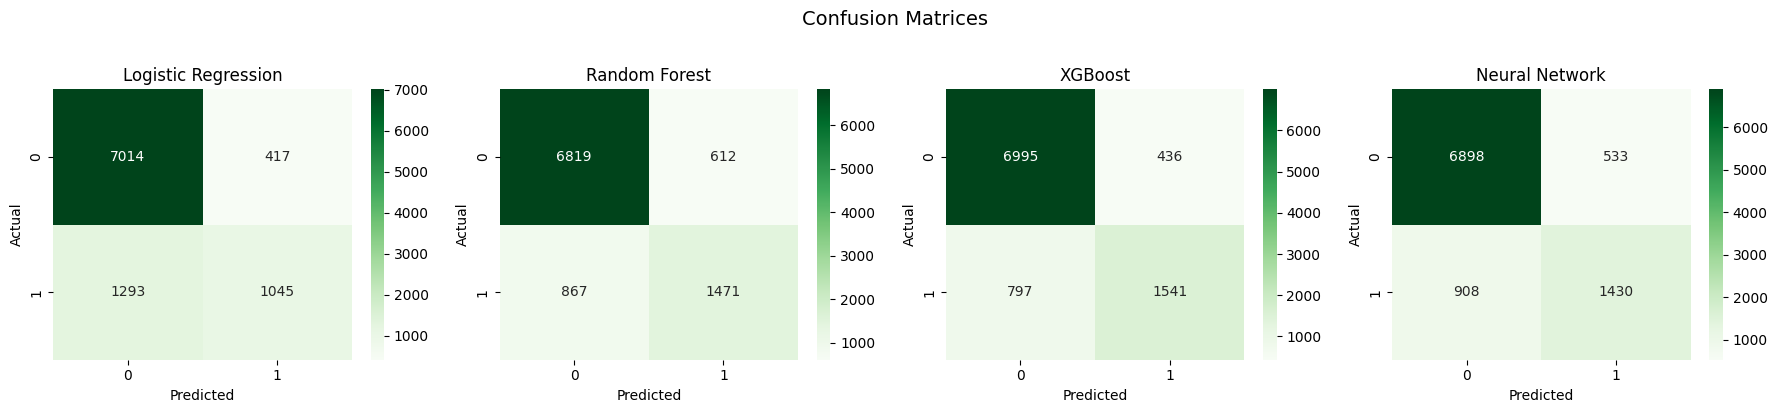

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, res in zip(axes, results):
    sns.heatmap(res['Confusion Matrix'], annot=True, fmt='d',
                cmap='Greens', ax=ax)
    ax.set_title(res['Model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#classification report for best model (XGBoost)
xgb_model = models['XGBoost']
y_pred_xgb = xgb_model.predict(X_test)
print('Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['<=50K', '>50K']))

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      7431
        >50K       0.78      0.66      0.71      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769



## SHAP Explainability (XGBoost)

SHAP (SHapley Additive exPlanations) reveals which features push predictions towards >50K or <=50K. The bar plot shows mean absolute impact; the beeswarm shows direction and magnitude per sample.

 99%|===================| 9693/9769 [01:13<00:00]       

Global Feature Importance mean |SHAP|


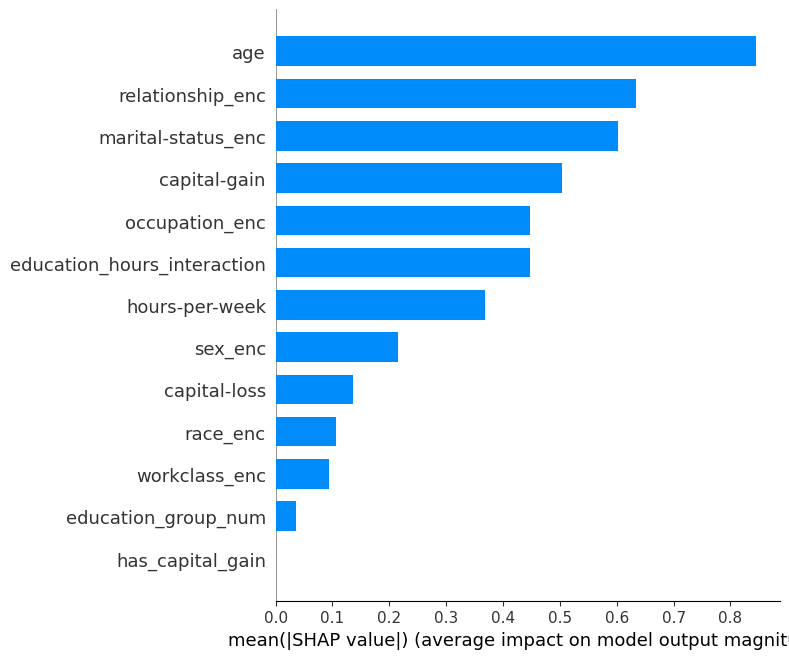


 Beeswarm Plot (direction & magnitude)


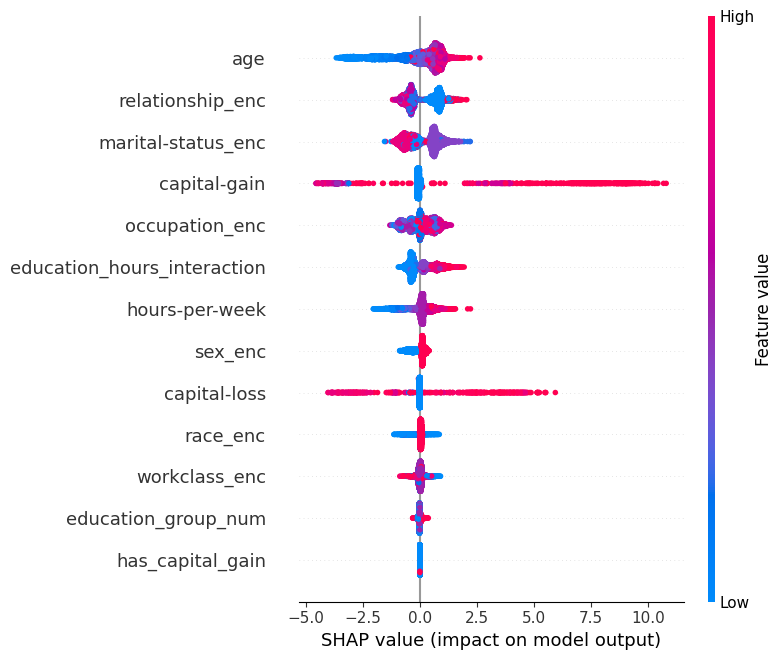

In [ ]:
explainer   = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# Global feature importance
print('Global Feature Importance mean |SHAP|')
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

# Beeswarm — direction and magnitude
print('\n Beeswarm Plot (direction & magnitude)')
shap.summary_plot(shap_values, X_test, show=True)

## Error Analysis

Understanding *where* the best model fails can guide future improvements, collecting better features for the groups it consistently misclassifies.

In [ ]:
error_df = X_test.copy()
error_df['actual']    = y_test.values
error_df['predicted'] = y_pred_xgb

false_positives = error_df[(error_df['actual'] == 0) & (error_df['predicted'] == 1)]
false_negatives = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)]

print(f'False Positives (predicted >50K, actually <=50K): {len(false_positives)}')
print(f'False Negatives (predicted <=50K, actually >50K): {len(false_negatives)}')

print('\n False Positives — Age & Hours distribution')
print(false_positives[['age', 'hours-per-week', 'education_group_num']].describe().round(2))

print('\n False Negatives — Age & Hours distribution')
print(false_negatives[['age', 'hours-per-week', 'education_group_num']].describe().round(2))

False Positives (predicted >50K, actually <=50K): 436
False Negatives (predicted <=50K, actually >50K): 797

 False Positives — Age & Hours distribution
          age  hours-per-week  education_group_num
count  436.00          436.00               436.00
mean    44.97           46.55                 1.40
std     10.11           11.39                 0.74
min     24.00            4.00                 0.00
25%     38.00           40.00                 1.00
50%     43.50           45.00                 2.00
75%     52.00           50.00                 2.00
max     90.00           99.00                 2.00

 False Negatives — Age & Hours distribution
          age  hours-per-week  education_group_num
count  797.00          797.00               797.00
mean    43.39           44.59                 0.76
std     11.63           12.71                 0.79
min     22.00            2.00                 0.00
25%     34.00           40.00                 0.00
50%     42.00           40.00        

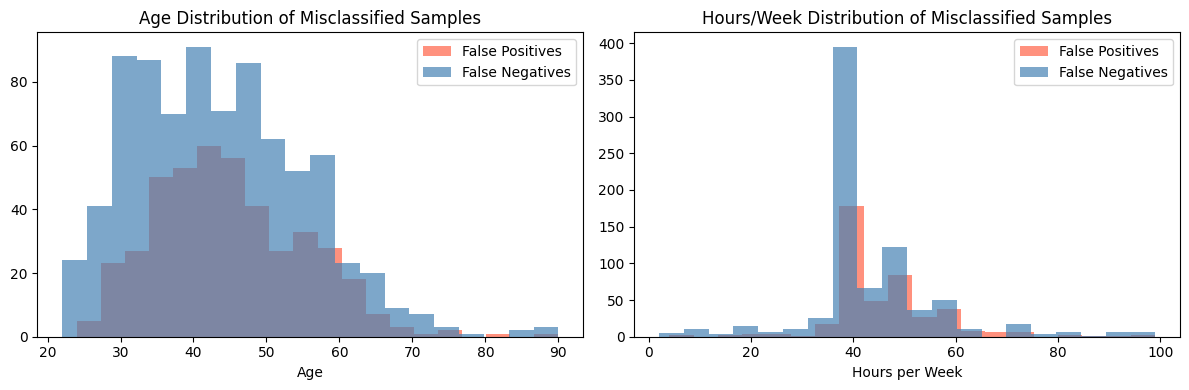

In [ ]:
# Visualise error patterns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(false_positives['age'], bins=20, color='tomato', alpha=0.7, label='False Positives')
axes[0].hist(false_negatives['age'], bins=20, color='steelblue', alpha=0.7, label='False Negatives')
axes[0].set_title('Age Distribution of Misclassified Samples')
axes[0].set_xlabel('Age')
axes[0].legend()

axes[1].hist(false_positives['hours-per-week'], bins=20, color='tomato', alpha=0.7, label='False Positives')
axes[1].hist(false_negatives['hours-per-week'], bins=20, color='steelblue', alpha=0.7, label='False Negatives')
axes[1].set_title('Hours/Week Distribution of Misclassified Samples')
axes[1].set_xlabel('Hours per Week')
axes[1].legend()

plt.tight_layout()
plt.show()